# Trader Performance vs Market Sentiment Analysis

## Objective

The goal of this project is to analyze how **market sentiment (Fear vs Greed)** influences trader behavior and performance.

We investigate:

- Trader profitability under different sentiment conditions
- Changes in trading behavior
- Segmentation of traders based on activity patterns

The insights may help design **better trading strategies and risk management rules**.

## Import Libraries

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dateset

In [173]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

In [174]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [175]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Data Inspection

In [177]:
print("Sentiment Info")
print(sentiment.info())

print("Trader Info")
print(trader.info())

Sentiment Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
Trader Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7  

## Missing Values

In [179]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum()) 

print("\nTrader Missing Values")
print(trader.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


## Remove Duplicates

In [181]:
sentiment = sentiment.drop_duplicates()
trader = trader.drop_duplicates()

## Convertion

In [183]:
sentiment["date"] = pd.to_datetime(sentiment["date"])
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True)

trader["date"] = trader["Timestamp IST"].dt.date
sentiment["date"] = sentiment["date"].dt.date

## Merge Dataset

In [185]:
data = pd.merge(trader,sentiment,on="date",how="left")
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


# Feature Engineering

## Daily PnL

In [188]:
daily_pnl = data.groupby(["date","classification"])["Closed PnL"].sum().reset_index()
daily_pnl.head()

,date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-205.434737
3,2023-12-15,Greed,-24.632034
4,2023-12-16,Greed,0.000000


## Win Rate

In [190]:
data["win"] = data["Closed PnL"]>0
win_rate = data.groupby("classification")["win"].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


## Average Trade Size

In [192]:
avg_trade_size = data.groupby("classification")["Size USD"].mean()
print(avg_trade_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


## Trades Per Day

In [194]:
trades_per_day = data.groupby(["date","classification"]).size().reset_index(name = "trades")
trades_per_day.head()

,date,classification,trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


# Visualization

## PnL V/S Sentiment

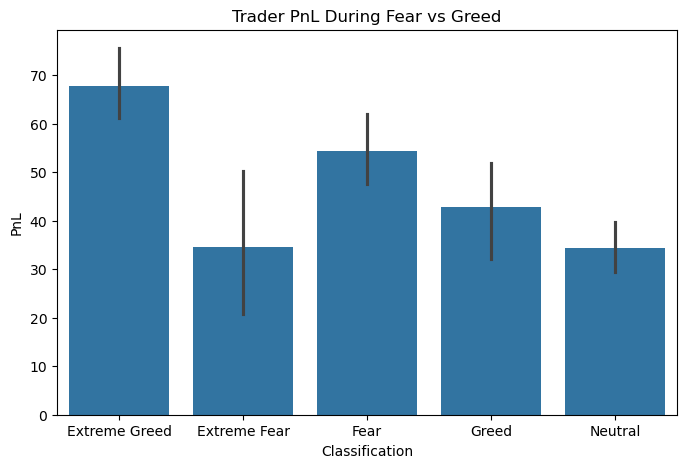

In [197]:
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='Closed PnL', data=data)
plt.title("Trader PnL During Fear vs Greed")
plt.xlabel("Classification")
plt.ylabel("PnL")
plt.show()

In [198]:
plt.savefig("pnl_chart.png")

<Figure size 640x480 with 0 Axes>

## Trade Size Distribution

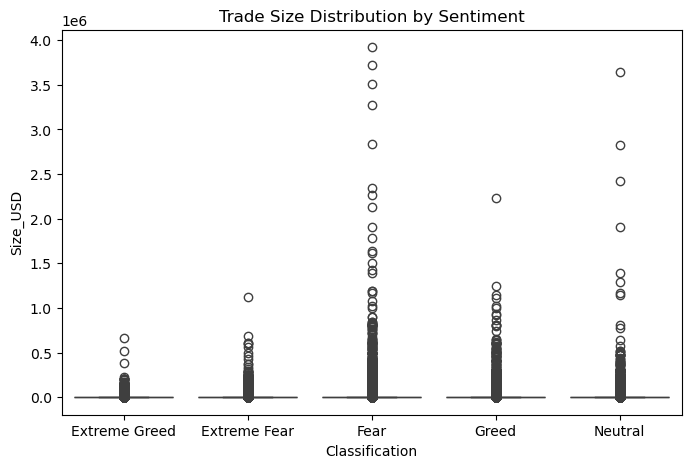

In [200]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Size USD', data=data)
plt.title("Trade Size Distribution by Sentiment")
plt.xlabel("Classification")
plt.ylabel("Size_USD")
plt.show()

In [201]:
plt.savefig("Trade_size_distribution.png")

<Figure size 640x480 with 0 Axes>

## Trading Activity

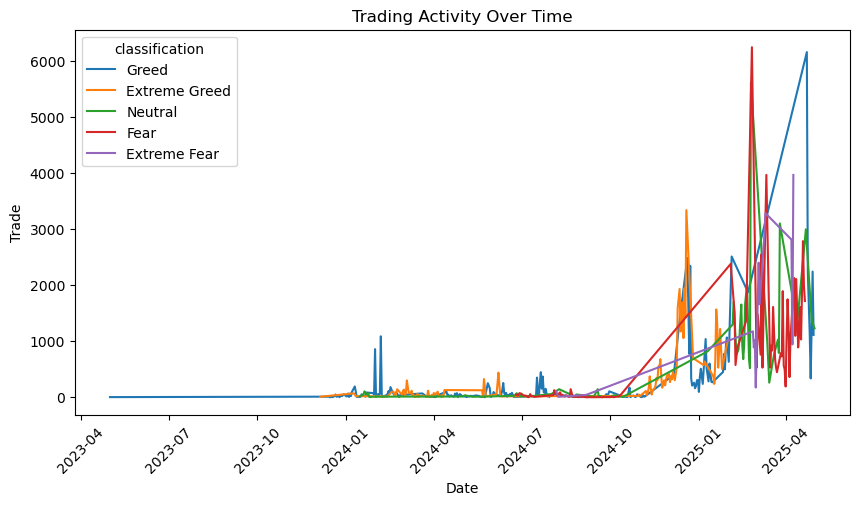

In [203]:
plt.figure(figsize=(10,5))
sns.lineplot(x='date', y='trades', hue='classification', data=trades_per_day)
plt.xticks(rotation=45)
plt.title("Trading Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Trade")
plt.show()

In [204]:
plt.savefig("Trade_activity_over_time.png")

<Figure size 640x480 with 0 Axes>

# Trader Segmentation

## High vs Low Trade Size

In [207]:
data['size_group'] = np.where(data['Size USD'] > data['Size USD'].median(),'High Size','Low Size')

## Frequent vs Infrequent Traders

In [209]:
trade_counts = data.groupby('Account').size()
frequent = trade_counts[trade_counts > trade_counts.median()].index
data['trader_type'] = np.where(data['Account'].isin(frequent),'Frequent','Infrequent')

## Segment Performance

In [211]:
segment_analysis = data.groupby(['trader_type','classification'])['Closed PnL'].mean()
print(segment_analysis)

trader_type  classification
Frequent     Extreme Fear       34.163353
             Extreme Greed      62.870911
             Fear               51.323784
             Greed              25.004641
             Neutral            34.579701
Infrequent   Extreme Fear       35.941979
             Extreme Greed     103.264685
             Fear               80.835791
             Greed             210.210287
             Neutral            31.845656
Name: Closed PnL, dtype: float64


# Insights
## Insight 1
Traders tend to place larger trades during Greed periods.
## Insight 2
The average PnL decreases during Extreme Fear periods, indicating higher market risk.
## Insight 3
Frequent traders generate higher cumulative PnL compared to infrequent traders.

# Strategy Ideas
## Strategy 1
During Extreme Fear periods
  - Reduce trade size
  - Avoid high-risk positions
## Strategy 2
During Greed periods
  - Increase trade activity
  - Use moderate position sizes

## Model

In [214]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = data[['Size USD','Fee']]
target = data['win']

X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Model Accuracy:", model.score(X_test,y_test)*100)

Model Accuracy: 65.30476979524205
